In [ ]:
#! pip install pdfplumber -q

In [1]:
import re
import requests

import pdfplumber
import pandas as pd

from io import BytesIO
from pathlib import Path 
from bs4 import BeautifulSoup
from urllib.parse import quote
from zoneinfo import ZoneInfo

In [2]:

THIS_FOLDER = Path('.')

ABT_FOLDER = THIS_FOLDER / 'abt'


In [3]:

BASE = "https://www.bcb.gov.br"

def get_atas_antigas():
    """
    Obtém as atas antigas do Copom, que estão disponíveis em formato HTML. 
    A partir de 2017, as atas passaram a ser disponibilizadas em formato PDF, 
    e as atas anteriores a essa data estão disponíveis em formato HTML.
    
    """
    url = f"{BASE}/api/servico/sitebcb/atascopom-conteudo/ultimas?quantidade=1000&filtro="
    r = requests.get(url)
    r.raise_for_status()
    data = r.json()["conteudo"]
    
    df = pd.DataFrame(data)[["DataReferencia", "Titulo", "LinkPagina"]]
    df["Tipo"] = "html"
    return df

def get_atas_novas():
    """
    Obtém as atas novas do Copom, que estão disponíveis em formato PDF. 
    A partir de 2017, as atas passaram a ser disponibilizadas em formato PDF, 
    e as atas anteriores a essa data estão disponíveis em formato HTML.
    """

    url = f"{BASE}/api/servico/sitebcb/atascopom/ultimas?quantidade=1000&filtro="
    r = requests.get(url)
    r.raise_for_status()
    data = r.json()["conteudo"]
    
    df = pd.DataFrame(data)[["DataReferencia", "Titulo", "Url"]]
    df = df.rename(columns={"Url": "LinkPagina"})
    df["Tipo"] = "pdf"
    return df


In [4]:

def extrair_html(link):

    codigo = re.search(r"\d+", link).group()
    filtro = quote(f"IdentificadorUrl eq '{codigo}'", safe=" ='")
    
    url = f"{BASE}/api/servico/sitebcb/atascopom-conteudo/principal?filtro={filtro}"
    r = requests.get(url)
    r.raise_for_status()
    
    data = r.json()["conteudo"][-1]

    if not data:
        print(f"❌ Não foi possível extrair o conteúdo da ata no link: {link}")
        return ""

    html = data["OutrasInformacoes"]
    
    soup = BeautifulSoup(html, "html.parser")
    return soup.get_text(separator=" ", strip=True)


In [5]:

def extrair_pdf(link):

    url = BASE + link if link.startswith("/") else link
    r = requests.get(url)
    r.raise_for_status()
    
    texto = ""
    try:

        with pdfplumber.open(BytesIO(r.content)) as pdf:
            for page in pdf.pages:
                texto += page.extract_text() + "\n"
    
    except Exception as e:
        print(f"❌ Não foi possível extrair o conteúdo da ata no link: {link}")
        print(f"Erro: {e}")

    return texto


In [6]:

def extrair_texto(row):
    if row["Tipo"] == "html":
        try:
            return extrair_html(row["LinkPagina"])
        except Exception as e:
            print(f"❌ Erro ao extrair HTML: {e}")
            print(f"Link: {row['LinkPagina']}")
    else:
        try:
            return extrair_pdf(row["LinkPagina"])
        except Exception as e:
            print(f"❌ Erro ao extrair PDF: {e}")
            print(f"Link: {row['LinkPagina']}")


In [7]:

df = pd.concat([get_atas_antigas(), get_atas_novas()], ignore_index=True)
df.head()

,DataReferencia,Titulo,LinkPagina,Tipo
0,2016-06-08T03:00:00Z,199ª Reunião,/publicacoes/atascopom/08062016,html
1,2016-04-27T03:00:00Z,198ª Reunião,/publicacoes/atascopom/27042016,html
2,2016-03-02T03:00:00Z,197ª Reunião,/publicacoes/atascopom/02032016,html
3,2016-01-20T02:00:00Z,196ª Reunião,/publicacoes/atascopom/20012016,html
4,2015-11-25T02:00:00Z,195ª Reunião,/publicacoes/atascopom/25112015,html


In [8]:

df["Texto"] = df.apply(
    extrair_texto, 
    axis=1
)


❌ Não foi possível extrair o conteúdo da ata no link: /content/copom/atascopom/COPOM220-not20190206220.pdf
Erro: Invalid dictionary construct: [/'P', 39, 0, /'Type', /'StructElem', /'K', [0], /'Pg', <PDFObjRef:21>]
❌ Não foi possível extrair o conteúdo da ata no link: /content/copom/atascopom/COPOM219-not20181212219.pdf
Erro: Invalid dictionary construct: [/'P', 38, 0, /'Type', /'StructElem', /'K', [0], /'Pg', <PDFObjRef:21>]
❌ Não foi possível extrair o conteúdo da ata no link: /content/copom/atascopom/COPOM217-not20180919217.pdf
Erro: Invalid dictionary construct: [/'P', 35, 0, /'Type', /'StructElem', /'K', [0], /'Pg', <PDFObjRef:20>]
❌ Erro ao extrair PDF: 'NoneType' object has no attribute 'startswith'
Link: None
❌ Erro ao extrair PDF: 'NoneType' object has no attribute 'startswith'
Link: None
❌ Erro ao extrair PDF: 'NoneType' object has no attribute 'startswith'
Link: None
❌ Erro ao extrair PDF: 'NoneType' object has no attribute 'startswith'
Link: None
❌ Erro ao extrair PDF: 'Non

In [14]:

# format 2016-06-08T03:00:00Z
fmt = '%Y-%m-%dT%H:%M:%S%z'
tz = ZoneInfo("America/Sao_Paulo")

df['date'] = pd.to_datetime(df['DataReferencia'], format=fmt).dt.tz_convert(tz).dt.date
df.set_index('date', inplace=True)
df


,DataReferencia,Titulo,LinkPagina,Tipo,Texto
date,,,,,
2016-06-08,2016-06-08T03:00:00Z,199ª Reunião,/publicacoes/atascopom/08062016,html,Sumário Evolução recente da economia Avaliação...
2016-04-27,2016-04-27T03:00:00Z,198ª Reunião,/publicacoes/atascopom/27042016,html,Sumário Evolução recente\nda economia Avaliaçã...
2016-03-02,2016-03-02T03:00:00Z,197ª Reunião,/publicacoes/atascopom/02032016,html,Sumário Evolução recente\nda economia Avaliaçã...
2016-01-20,2016-01-20T02:00:00Z,196ª Reunião,/publicacoes/atascopom/20012016,html,Sumário Evolução recente\nda economia Avaliaçã...
2015-11-25,2015-11-25T02:00:00Z,195ª Reunião,/publicacoes/atascopom/25112015,html,Sumário Evolução recente\nda economia Avaliaçã...
...,...,...,...,...,...
1998-06-24,1998-06-24T03:00:00Z,25ª Reunião,None,pdf,None
1998-05-20,1998-05-20T03:00:00Z,24ª Reunião,None,pdf,None
1998-04-15,1998-04-15T03:00:00Z,23ª Reunião,None,pdf,None


0     2016-06-08
1     2016-04-27
2     2016-03-02
3     2016-01-20
4     2015-11-25
         ...    
431   1998-06-24
432   1998-05-20
433   1998-04-15
434   1998-03-04
435   1998-01-28
Name: date, Length: 436, dtype: datetime64[ns]

In [17]:
from datetime import datetime, timedelta


codigo_serie = 432
url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_serie}/dados?formato=json"

params = {
    'formato': 'json',
    'dataInicial': None,
    'dataFinal': None
}

dfs = []
years = (
    pd.to_datetime(
        df.reset_index(drop=False)['date']
    ).dt
    .year
    .unique()
)

for year in years:
    params['dataInicial'] = f"01/01/{year}"
    params['dataFinal'] = f"31/12/{year}"

    response = requests.get(url, params=params)
    data = response.json()

    df_ano = pd.DataFrame(data)
    dfs.append(df_ano)

df_selic = pd.concat(dfs, ignore_index=True)

# Ajustar tipos
df_selic['data'] = pd.to_datetime(df_selic['data'], dayfirst=True)
df_selic['valor'] = pd.to_numeric(df_selic['valor'])

# Ordenar por data
df_selic = df_selic.sort_values('data')

print(df_selic.tail())

           data  valor                                               erro
6630 2026-04-27  14.75                                                NaN
6631 2026-04-28  14.75                                                NaN
6632 2026-04-29  14.75                                                NaN
6512        NaT    NaN                                                404
6513        NaT    NaN  br.gov.bcb.pec.sgs.comum.excecoes.SGSNegocioEx...


In [18]:

df_selic[~df_selic['erro'].isna()]


,data,valor,erro
6512,NaT,NaN,404
6513,NaT,NaN,br.gov.bcb.pec.sgs.comum.excecoes.SGSNegocioEx...


In [19]:

df_selic['date'] = pd.to_datetime(df_selic['data'], format='%Y-%m-%d')
df_selic.set_index('date', inplace=True)
df_selic.head()


,data,valor,erro
date,,,
1999-03-05,1999-03-05,45.0,NaN
1999-03-06,1999-03-06,45.0,NaN
1999-03-07,1999-03-07,45.0,NaN
1999-03-08,1999-03-08,45.0,NaN
1999-03-09,1999-03-09,45.0,NaN


<Axes: title={'center': 'Taxa Selic ao Longo do Tempo'}, xlabel='date'>

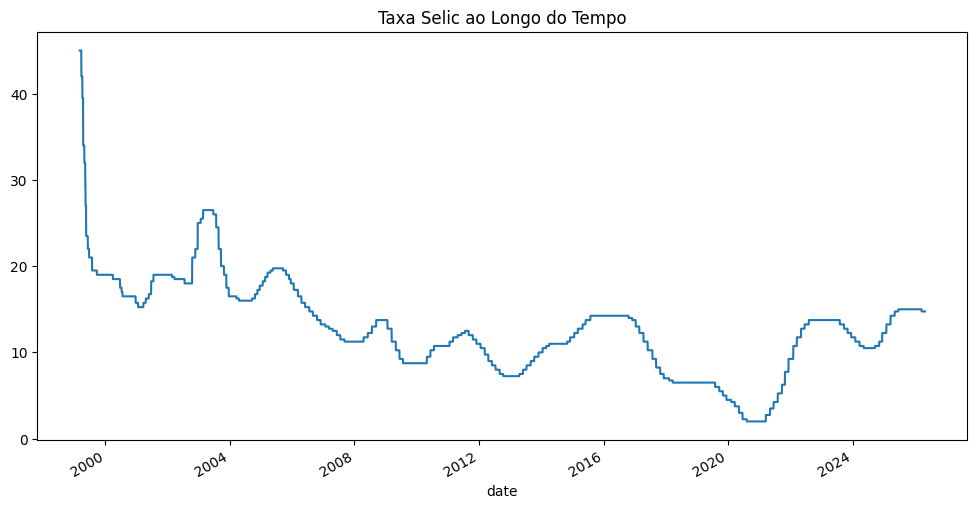

In [20]:

df_selic['valor'].plot(figsize=(12, 6), title='Taxa Selic ao Longo do Tempo')


In [21]:

df_selic.drop(columns=['data', 'erro'], inplace=True)



In [22]:

df_selic.rename(columns={'valor': 'selic'}, inplace=True)
df_selic.dropna(inplace=True)
df_selic


,selic
date,
1999-03-05,45.00
1999-03-06,45.00
1999-03-07,45.00
1999-03-08,45.00
1999-03-09,45.00
...,...
2026-04-25,14.75
2026-04-26,14.75
2026-04-27,14.75


In [95]:

df_final = df.join(df_selic, how='left')
df_final.drop(['LinkPagina', 'Tipo'], axis=1, inplace=True)

df_final.head()


,DataReferencia,Titulo,Texto,selic
date,,,,
2016-06-08,2016-06-08T03:00:00Z,199ª Reunião,Sumário Evolução recente da economia Avaliação...,14.25
2016-04-27,2016-04-27T03:00:00Z,198ª Reunião,Sumário Evolução recente\nda economia Avaliaçã...,14.25
2016-03-02,2016-03-02T03:00:00Z,197ª Reunião,Sumário Evolução recente\nda economia Avaliaçã...,14.25
2016-01-20,2016-01-20T02:00:00Z,196ª Reunião,Sumário Evolução recente\nda economia Avaliaçã...,14.25
2015-11-25,2015-11-25T02:00:00Z,195ª Reunião,Sumário Evolução recente\nda economia Avaliaçã...,14.25


In [96]:
#  Remove casos em que nao havia SELIC ainda
filtro_data = (
    pd.to_datetime(df_final['DataReferencia']).dt.date 
    >= df_selic.index.min().date()
)
df_final = df_final[filtro_data]

# Ordena por data referencia
df_final.sort_values('DataReferencia', inplace=True, ascending=True, ignore_index=True)
df_final.reset_index(drop=True, inplace=True)

df_final.head()


,DataReferencia,Titulo,Texto,selic
0,1999-04-01T03:00:00Z,34ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,42.0
1,1999-04-14T03:00:00Z,34ª Reunião,None,39.5
2,1999-05-01T03:00:00Z,35ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,32.0
3,1999-05-19T03:00:00Z,35ª Reunião,None,27.0
4,1999-06-01T03:00:00Z,36ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,23.5


In [98]:

df_final['selic_next'] = df_final['selic'].shift(-1)
df_final['selic_next_var'] = df_final['selic_next'] - df_final['selic']

# Drop na
df_final.dropna(inplace=True)
df_final.reset_index(drop=True, inplace=True)

# Gera um indicador de sequencia
df_final.reset_index(drop=False, inplace=True)
df_final.rename(columns={'index': 'Sequencia'}, inplace=True)


# df_final['selic_lag_1'] = df_final['selic'].shift(1)
# df_final['selic_var_lag_1'] = df_final['selic'] - df_final['selic_lag_1']

# df_final['selic_lag_2'] = df_final['selic'].shift(2)
# df_final['selic_var_lag_2'] = df_final['selic'] - df_final['selic_lag_2']

# df_final['selic_lag_3'] = df_final['selic'].shift(3)
# df_final['selic_var_lag_3'] = df_final['selic'] - df_final['selic_lag_3']

# df_final['selic_lag_4'] = df_final['selic'].shift(4)
# df_final['selic_var_lag_4'] = df_final['selic'] - df_final['selic_lag_4']

# df_final['selic_lag_5'] = df_final['selic'].shift(5)
# df_final['selic_var_lag_5'] = df_final['selic'] - df_final['selic_lag_5']

# df_final['selic_lag_6'] = df_final['selic'].shift(6)
# df_final['selic_var_lag_6'] = df_final['selic'] - df_final['selic_lag_6']


In [99]:

# Remove colunas utilitarias
#df_final.drop('DataReferencia', axis=1, inplace=True)

display(df_final.head())
display(df_final.tail())


,Sequencia,DataReferencia,Titulo,Texto,selic,selic_next,selic_next_var
0,0,1999-04-01T03:00:00Z,34ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,42.0,32.0,-10.0
1,1,1999-05-01T03:00:00Z,35ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,32.0,23.5,-8.5
2,2,1999-06-01T03:00:00Z,36ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,23.5,21.0,-2.5
3,3,1999-07-01T03:00:00Z,37ª Reunião,Sumário Preços e nível de atividade Agregados ...,21.0,19.5,-1.5
4,4,1999-09-01T03:00:00Z,38ª Reunião,Sumário Demanda e oferta agregadas Preços Agre...,19.5,19.5,0.0


,Sequencia,DataReferencia,Titulo,Texto,selic,selic_next,selic_next_var
237,237,2025-06-18T03:00:00Z,"271ª Reunião - 17-18 junho, 2025",271ª\nAta da Reunião do\nComitê de Política Mo...,14.75,15.0,0.25
238,238,2025-07-30T03:00:00Z,"272ª Reunião - 29-30 julho, 2025",272ª\nAta da Reunião do\nComitê de Política Mo...,15.00,15.0,0.00
239,239,2025-09-17T03:00:00Z,"273ª Reunião - 16-17 setembro, 2025",273ª\nAta da Reunião do\nComitê de Política Mo...,15.00,15.0,0.00
240,240,2025-11-05T03:00:00Z,"274ª Reunião - 4-5 novembro, 2025",274ª\nAta da Reunião do\nComitê de Política Mo...,15.00,15.0,0.00
241,241,2025-12-10T03:00:00Z,"275ª Reunião - 9-10 dezembro, 2025",275ª\nAta da Reunião do\nComitê de Política Mo...,15.00,15.0,0.00


In [100]:

df_final = df_final[~df_final['Texto'].isna()]
display(df_final)


,Sequencia,DataReferencia,Titulo,Texto,selic,selic_next,selic_next_var
0,0,1999-04-01T03:00:00Z,34ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,42.00,32.0,-10.00
1,1,1999-05-01T03:00:00Z,35ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,32.00,23.5,-8.50
2,2,1999-06-01T03:00:00Z,36ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,23.50,21.0,-2.50
3,3,1999-07-01T03:00:00Z,37ª Reunião,Sumário Preços e nível de atividade Agregados ...,21.00,19.5,-1.50
4,4,1999-09-01T03:00:00Z,38ª Reunião,Sumário Demanda e oferta agregadas Preços Agre...,19.50,19.5,0.00
...,...,...,...,...,...,...,...
237,237,2025-06-18T03:00:00Z,"271ª Reunião - 17-18 junho, 2025",271ª\nAta da Reunião do\nComitê de Política Mo...,14.75,15.0,0.25
238,238,2025-07-30T03:00:00Z,"272ª Reunião - 29-30 julho, 2025",272ª\nAta da Reunião do\nComitê de Política Mo...,15.00,15.0,0.00
239,239,2025-09-17T03:00:00Z,"273ª Reunião - 16-17 setembro, 2025",273ª\nAta da Reunião do\nComitê de Política Mo...,15.00,15.0,0.00
240,240,2025-11-05T03:00:00Z,"274ª Reunião - 4-5 novembro, 2025",274ª\nAta da Reunião do\nComitê de Política Mo...,15.00,15.0,0.00


In [101]:

df_final.rename(
    columns={
        'Sequencia': 'sequencia',
        'Titulo': 'titulo',
        'Texto': 'texto',
        'selic': 'selic_atual',
        'selic_next_var': 'selic_next_var'
    },
    inplace=True
)
df_final.head()

,sequencia,DataReferencia,titulo,texto,selic_atual,selic_next,selic_next_var
0,0,1999-04-01T03:00:00Z,34ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,42.0,32.0,-10.0
1,1,1999-05-01T03:00:00Z,35ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,32.0,23.5,-8.5
2,2,1999-06-01T03:00:00Z,36ª Reunião,Sumário Preços e Nível de Atividade Agregados ...,23.5,21.0,-2.5
3,3,1999-07-01T03:00:00Z,37ª Reunião,Sumário Preços e nível de atividade Agregados ...,21.0,19.5,-1.5
4,4,1999-09-01T03:00:00Z,38ª Reunião,Sumário Demanda e oferta agregadas Preços Agre...,19.5,19.5,0.0


<Axes: title={'center': 'Taxa Selic ao Longo do Tempo'}>

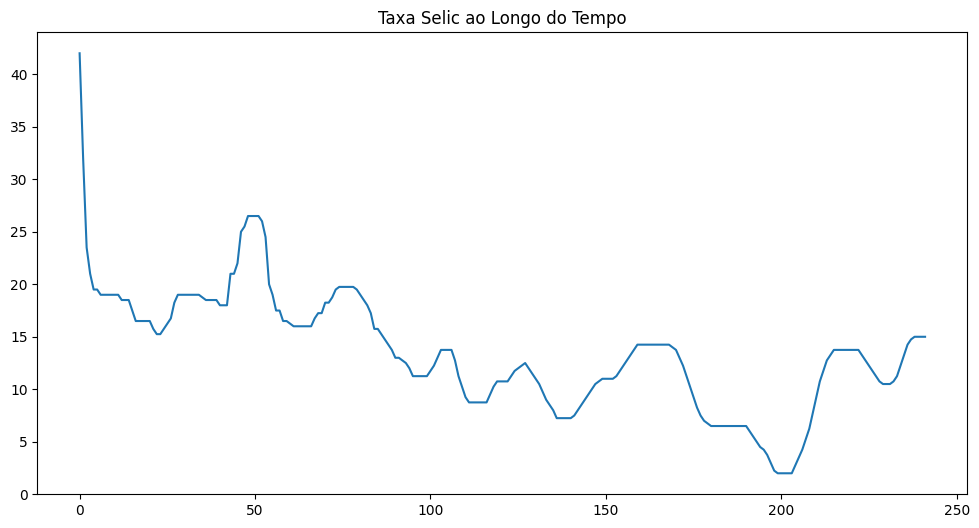

In [102]:

df_final['selic_atual'].plot(figsize=(12, 6), title='Taxa Selic ao Longo do Tempo')


<Axes: title={'center': 'Variação da Taxa Selic ao Longo do Tempo'}>

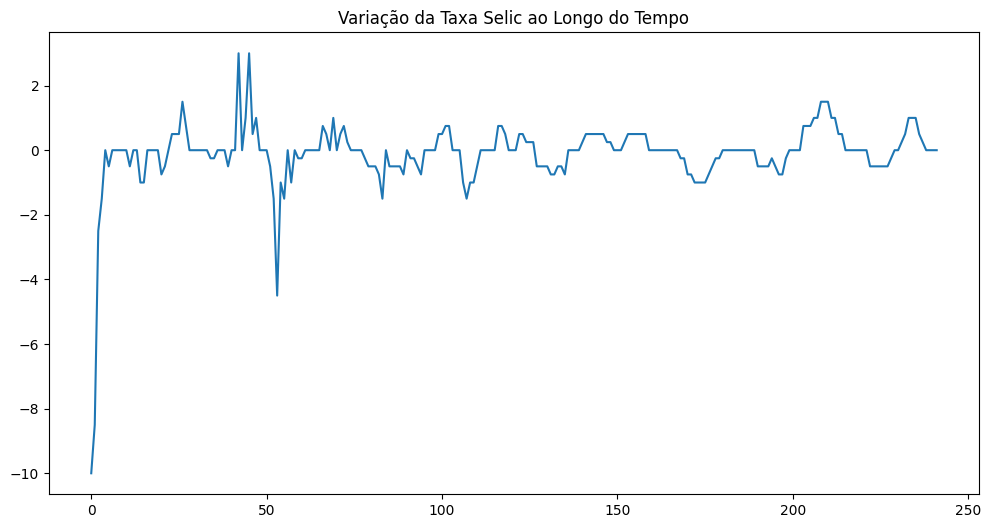

In [103]:

df_final['selic_next_var'].plot(figsize=(12, 6), title='Variação da Taxa Selic ao Longo do Tempo')


In [104]:


df_final.to_parquet(
    ABT_FOLDER / '2_abt_copom.parquet', 
    index=False,
)
